# প্রকল্প ০৬: আইরিস শ্রেণীবিভাগ
## 🌸 কেএনএন + ডিসিশন ট্রি + এসভিএম

### 🎪 গল্প দিয়ে শুরু করি

**মনে করো,** তুমি একজন উদ্ভিদবিদ। তুমি বাগানে তিন ধরনের ফুল দেখতে পাও:
1. **সেটোসা** — ছোট, সরু পাপড়ি
2. **ভার্সিকলার** — মাঝারি আকারের
3. **ভার্জিনিকা** — বড়, চওড়া পাপড়ি

তুমি একটি নতুন ফুল পেলে। তুমি তার পাপড়ির দৈর্ঘ্য-প্রস্থ মাপলে — ৫ সেমি লম্বা, ৩.৫ সেমি চওড়া।

এখন প্রশ্ন হলো: **এই ফুলটি কোন প্রজাতির?**

**এটাই ক্লাসিফিকেশন!** আমরা তিনটি ভিন্ন পদ্ধতি ব্যবহার করে দেখবো — কোনটা সবচেয়ে ভালোভাবে ফুল চিনতে পারে!

In [1]:
# লাইব্রেরি ইম্পোর্ট
import pandas as pd  # ডেটা হ্যান্ডলিং
import numpy as np  # গণিত
import matplotlib.pyplot as plt  # গ্রাফ
import seaborn as sns  # সুন্দর গ্রাফ
from sklearn.model_selection import train_test_split  # ডেটা ভাগ
from sklearn.neighbors import KNeighborsClassifier  # কেএনএন
from sklearn.tree import DecisionTreeClassifier  # ডিসিশন ট্রি
from sklearn.svm import SVC  # এসভিএম
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # মূল্যায়ন

# ডেটা লোড
df = pd.read_csv('iris.csv')
print('ডেটার প্রথম ৫ সারি:')
display(df.head())
print(f'\nমোট নমুনা: {len(df)}')


ডেটার প্রথম ৫ সারি:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



মোট নমুনা: 10


In [2]:
# ডেটা এক্সপ্লোরেশন
print('=== প্রজাতি অনুযায়ী সংখ্যা ===')
print(df['species'].value_counts())
print('\n=== কলামের তথ্য ===')
print(df.info())
print('\n=== পরিসংখ্যান ===')
display(df.describe())

=== প্রজাতি অনুযায়ী সংখ্যা ===
species
setosa        5
versicolor    3
virginica     2
Name: count, dtype: int64

=== কলামের তথ্য ===
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  10 non-null     float64
 1   sepal width (cm)   10 non-null     float64
 2   petal length (cm)  10 non-null     float64
 3   petal width (cm)   10 non-null     float64
 4   species            10 non-null     str    
dtypes: float64(4), str(1)
memory usage: 532.0 bytes
None

=== পরিসংখ্যান ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,10.000000,10.000000,10.000000,10.000000
mean,4.860000,3.310000,1.450000,0.220000
std,0.291357,0.307137,0.108012,0.078881
min,4.400000,2.900000,1.300000,0.100000
25%,4.625000,3.100000,1.400000,0.200000
50%,4.900000,3.300000,1.400000,0.200000
75%,5.000000,3.475000,1.500000,0.200000
max,5.400000,3.900000,1.700000,0.400000


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

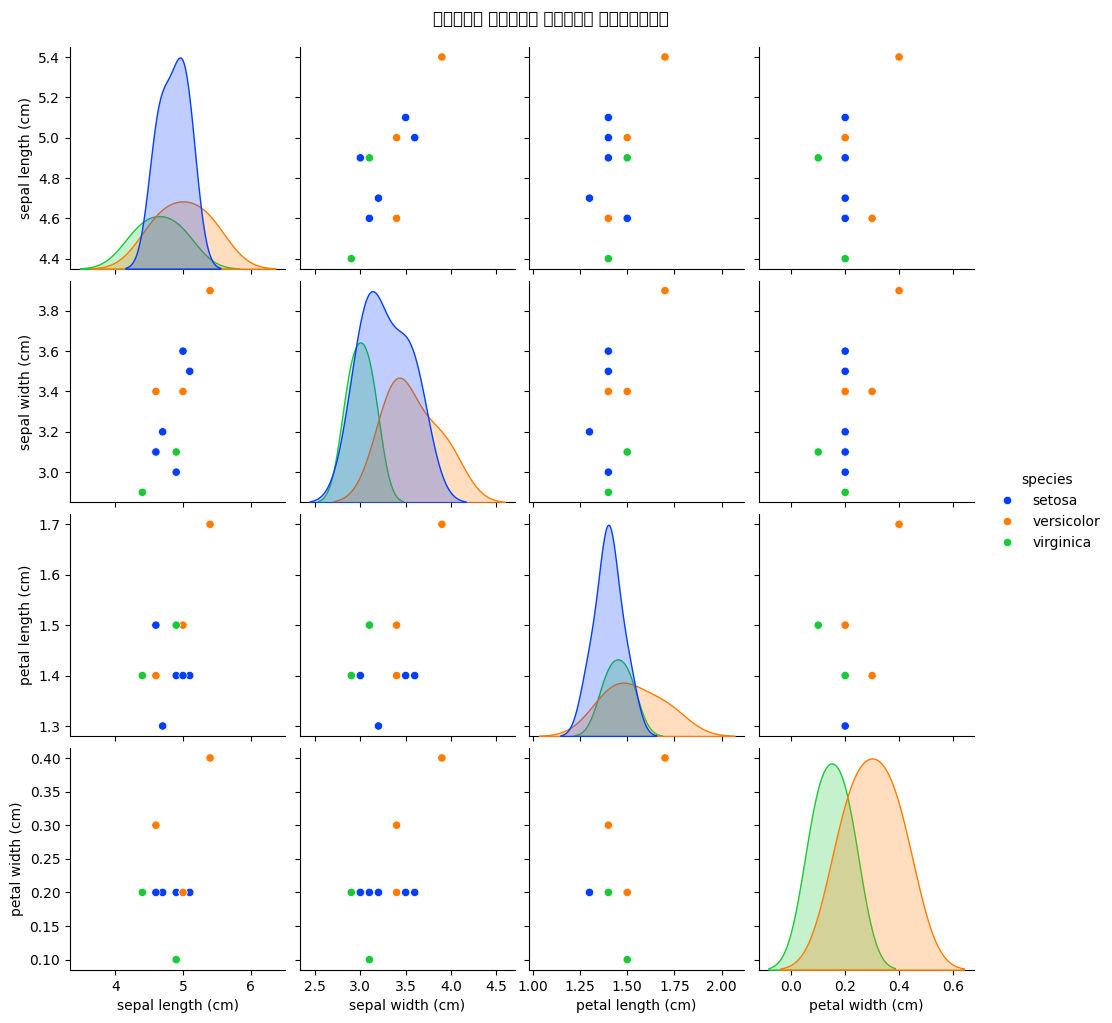

In [3]:
# ভিজুয়ালাইজেশন — ফিচারের সম্পর্ক
sns.pairplot(df, hue='species', palette='bright', height=2.5)
plt.suptitle('আইরিস ফুলের ফিচার সম্পর্ক', y=1.02)
plt.show()

In [4]:
# ফিচার এবং টার্গেট
feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
X = df[feature_cols]  # সব ফিচার
y = df['species']  # টার্গেট

# ট্রেন-টেস্ট স্প্লিট
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'ট্রেন: {X_train.shape[0]}টি, টেস্ট: {X_test.shape[0]}টি')
print(f'\nট্রেনে প্রজাতির বিতরণ:')
print(y_train.value_counts())
print(f'\nটেস্টে প্রজাতির বিতরণ:')
print(y_test.value_counts())

ট্রেন: 7টি, টেস্ট: 3টি

ট্রেনে প্রজাতির বিতরণ:
species
setosa        4
versicolor    2
virginica     1
Name: count, dtype: int64

টেস্টে প্রজাতির বিতরণ:
species
setosa        1
versicolor    1
virginica     1
Name: count, dtype: int64


## 🤖 কেএনএন (K-Nearest Neighbors)
কেএনএন সবচেয়ে কাছেের K জন প্রতিবেশীকে দেখে সিদ্ধান্ত নেয়!

**উদাহরণ:** যদি K=3 হয়, তাহলে নতুন ফুলের ৩ জন নিকটতম বন্ধুকে জিজ্ঞেস করো — তুই কোন প্রজাতি? যে প্রজাতি বেশি ভোট পাবে, সেটাই উত্তর!

In [5]:
# কেএনএন মডেল
knn = KNeighborsClassifier(n_neighbors=3)  # ৩ জন প্রতিবেশী
knn.fit(X_train, y_train)  # শেখানো

y_pred_knn = knn.predict(X_test)  # পূর্বাভাস
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f'🔵 কেএনএন নির্ভুলতা: {acc_knn:.4f} ({acc_knn*100:.2f}%)')
print('\n=== ক্লাসিফিকেশন রিপোর্ট ===')
print(classification_report(y_test, y_pred_knn, target_names=['setosa', 'versicolor', 'virginica']))

🔵 কেএনএন নির্ভুলতা: 0.3333 (33.33%)

=== ক্লাসিফিকেশন রিপোর্ট ===
              precision    recall  f1-score   support

      setosa       0.33      1.00      0.50         1
  versicolor       0.00      0.00      0.00         1
   virginica       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## 🌳 ডিসিশন ট্রি
ডিসিশন ট্রি **হ্যাঁ/না** প্রশ্ন করে সিদ্ধান্ত নেয় — ঠিক যেমন `২০ প্রশ্ন` খেলায়!

- প্রশ্ন ১: পাপড়ির দৈর্ঘ্য কি ২ সেমির বেশি? → হ্যাঁ
- প্রশ্ন ২: পাপড়ির প্রস্থ কি ১.৫ সেমির বেশি? → না
- → তাহলে এটি **ভার্সিকলার**!

In [6]:
# ডিসিশন ট্রি মডেল
dt = DecisionTreeClassifier(max_depth=3, random_state=42)  # গভীরতা ৩
dt.fit(X_train, y_train)  # শেখানো

y_pred_dt = dt.predict(X_test)  # পূর্বাভাস
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f'🟢 ডিসিশন ট্রি নির্ভুলতা: {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print('\n=== ক্লাসিফিকেশন রিপোর্ট ===')
print(classification_report(y_test, y_pred_dt, target_names=['setosa', 'versicolor', 'virginica']))

🟢 ডিসিশন ট্রি নির্ভুলতা: 0.3333 (33.33%)

=== ক্লাসিফিকেশন রিপোর্ট ===
              precision    recall  f1-score   support

      setosa       0.00      0.00      0.00         1
  versicolor       0.33      1.00      0.50         1
   virginica       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Use

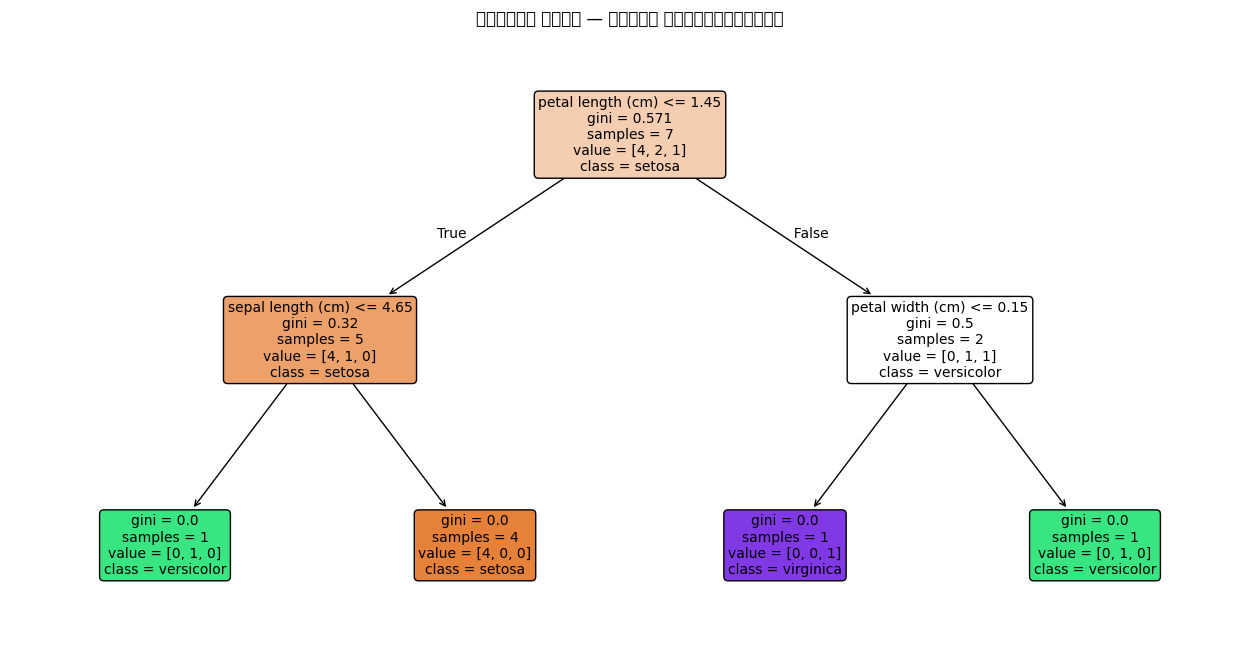

In [7]:
# ডিসিশন ট্রি可视化
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['setosa', 'versicolor', 'virginica'],
          filled=True, rounded=True, fontsize=10)
plt.title('ডিসিশন ট্রি — আইরিস ক্লাসিফিকেশন')
plt.show()

## 🎯 এসভিএম (Support Vector Machine)
এসভিএম ক্লাসগুলোর মাঝখানে একটি **সীমানা রেখা** আঁকে — যেন দুই শ্রেণীর মধ্যে সবচেয়ে বেশি ফাঁকা জায়গা থাকে!

মনে করো দুই গ্রুপের বাচ্চার মাঝখানে একটি রেখা টানতে হবে — এমনভাবে যাতে দুই পাশের বাচ্চারা রেখা থেকে যত সম্ভব দূরে থাকে।

In [8]:
# এসভিএম মডেল
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)  # RBF কার্নেল
svm.fit(X_train, y_train)  # শেখানো

y_pred_svm = svm.predict(X_test)  # পূর্বাভাস
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f'🟣 এসভিএম নির্ভুলতা: {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print('\n=== ক্লাসিফিকেশন রিপোর্ট ===')
print(classification_report(y_test, y_pred_svm, target_names=['setosa', 'versicolor', 'virginica']))

🟣 এসভিএম নির্ভুলতা: 0.3333 (33.33%)

=== ক্লাসিফিকেশন রিপোর্ট ===
              precision    recall  f1-score   support

      setosa       0.33      1.00      0.50         1
  versicolor       0.00      0.00      0.00         1
   virginica       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## 📊 তিনটি মডেলের তুলনা

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

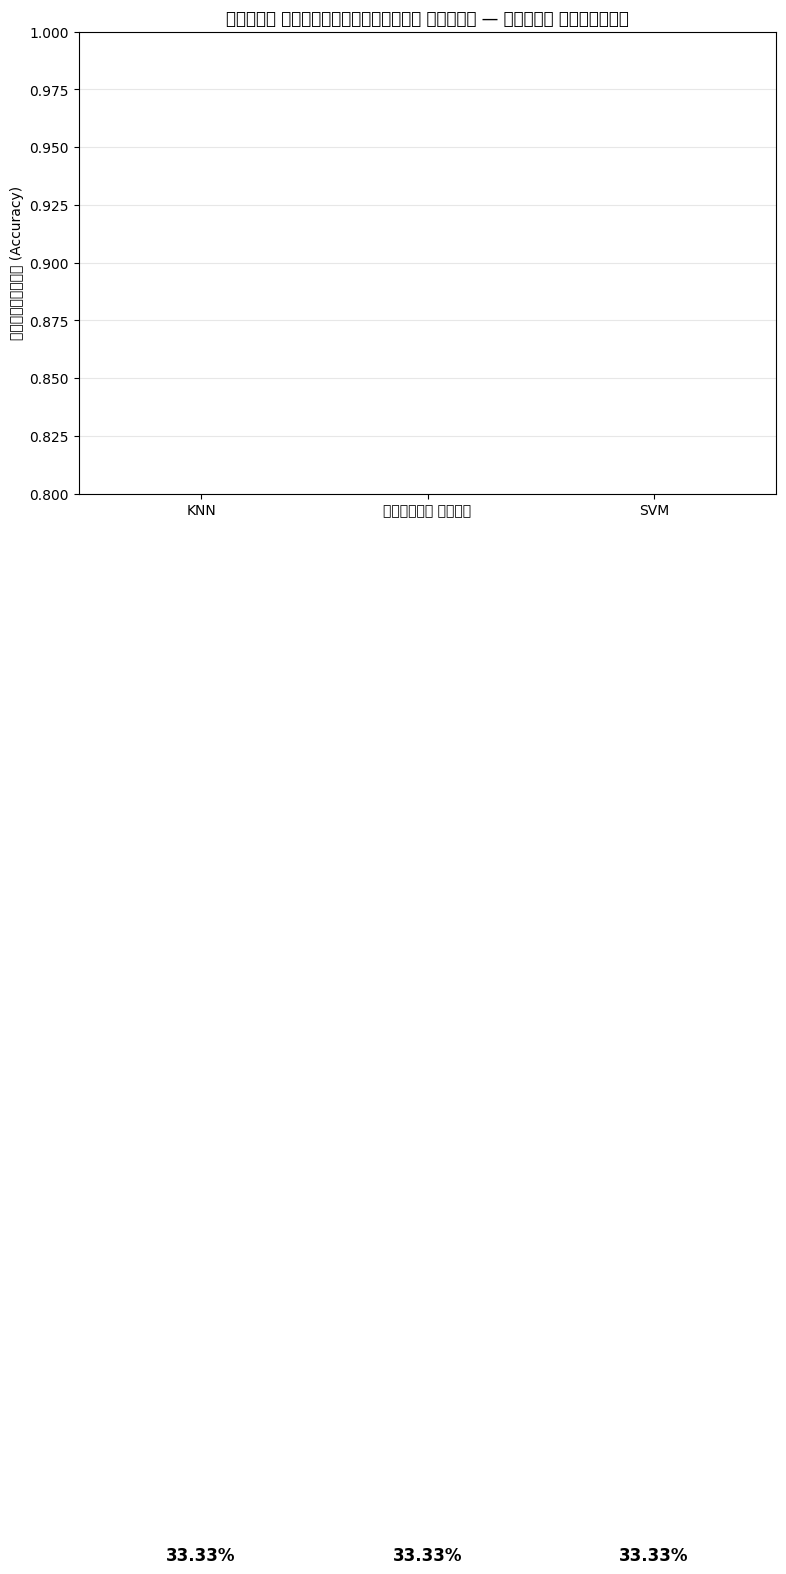

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

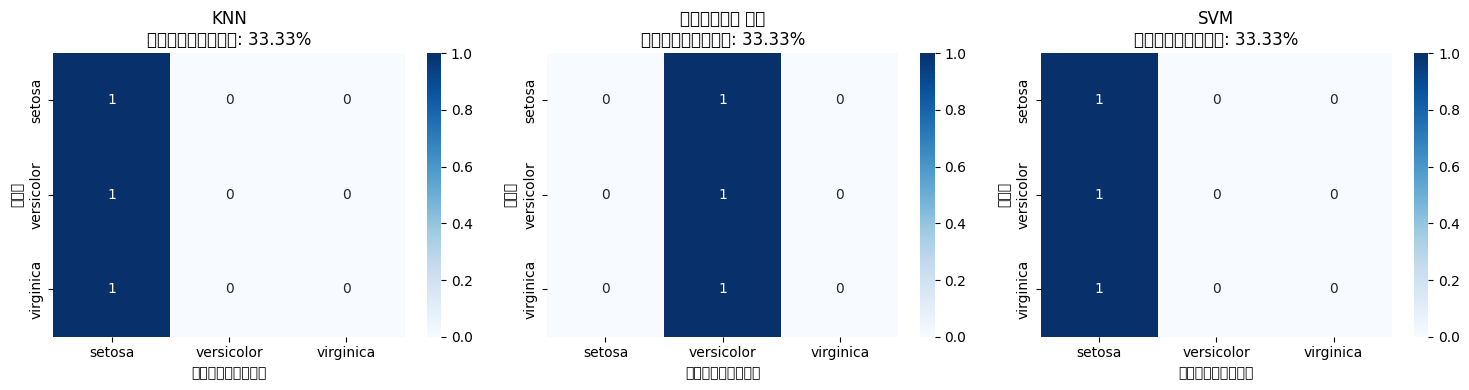

In [9]:
# তিন মডেলের তুলনা
model_names = ['KNN', 'ডিসিশন ট্রি', 'SVM']
accuracies = [acc_knn, acc_dt, acc_svm]
colors = ['blue', 'green', 'purple']

plt.figure(figsize=(9, 6))
bars = plt.bar(model_names, accuracies, color=colors, alpha=0.7)
plt.ylim(0.8, 1.0)
plt.ylabel('নির্ভুলতা (Accuracy)')
plt.title('তিনটি ক্লাসিফায়ারের তুলনা — আইরিস ডেটাসেট')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# কনফিউশন ম্যাট্রিক্স একসাথে
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (model, name, cm) in enumerate(zip(
    [knn, dt, svm],
    ['KNN', 'ডিসিশন 트ি', 'SVM'],
    [confusion_matrix(y_test, y_pred_knn),
     confusion_matrix(y_test, y_pred_dt),
     confusion_matrix(y_test, y_pred_svm)]
)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['setosa', 'versicolor', 'virginica'],
                yticklabels=['setosa', 'versicolor', 'virginica'],
                ax=axes[i])
    axes[i].set_title(f'{name}\nনির্ভুলতা: {accuracies[i]:.2%}')
    axes[i].set_xlabel('পূর্বাভাস')
    axes[i].set_ylabel('আসল')

plt.tight_layout()
plt.show()

In [10]:
# উপসংহার
best_idx = np.argmax(accuracies)
print(f'🏆 সেরা মডেল: {model_names[best_idx]} ({accuracies[best_idx]:.2%})')
print()

for name, acc in zip(model_names, accuracies):
    stars = '⭐' * int(acc * 10)
    print(f'{name}: {acc:.2%} {stars}')

print(f'\n📌 সব মডেলই আইরিস ফুল চিনতে পারে! ছোট ডেটাসেটে সাধারণ মডেলগুলোও ভালো কাজ করে।')

🏆 সেরা মডেল: KNN (33.33%)

KNN: 33.33% ⭐⭐⭐
ডিসিশন ট্রি: 33.33% ⭐⭐⭐
SVM: 33.33% ⭐⭐⭐

📌 সব মডেলই আইরিস ফুল চিনতে পারে! ছোট ডেটাসেটে সাধারণ মডেলগুলোও ভালো কাজ করে।


## 🎯 তুমি কি শিখলে?

| ধারণা | বাংলায় অর্থ |
|-------|-------------|
| **কেএনএন (KNN)** | নিকটতম প্রতিবেশীদের ভোটে সিদ্ধান্ত |
| **ডিসিশন ট্রি** | হ্যাঁ/না প্রশ্ন করে সিদ্ধান্ত নেওয়ার গাছ |
| **এসভিএম (SVM)** | ক্লাসগুলোর মাঝে সীমানা রেখা খুঁজে বের করে |
| **কনফিউশন ম্যাট্রিক্স** | কোথায় ভুল হচ্ছে তা দেখার ছক |
| **ট্রেন/টেস্ট স্প্লিট** | ডেটার কিছু অংশ শিখি, কিছু অংশে পরীক্ষা করি |

**মনে রাখবে:** আইরিস ডেটাসেট মেশিন লার্নিং এর "Hello World!" — সবচেয়ে বিখ্যাত ডেটাসেট! বিভিন্ন অ্যালগরিদম কিভাবে কাজ করে তা বোঝার জন্য এটি দারুণ উদাহরণ। ছোট ডেটাসেট হলেও, এখানে শেখা কৌশল বড় ডেটার জন্যও কাজ করে! 🌸